In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
!pip install iminuit
!pip install
from iminuit import Minuit

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try 'pacman -S
    python-xyz', where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Arch-packaged Python package,
    create a virtual environment using 'python -m venv path/to/venv'.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip.
    
    If you wish to install a non-Arch packaged Python application,
    it may be easiest to use 'pipx install xyz', which will manage a
    virtual environment for you. Make sure you have python-pipx
    installed via pacman.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detailed specification.
error: externally-managed-environment

× This environment is externally managed
╰

In [2]:
import os

path = "../DMSO"
all_files = os.listdir(path)
csv_files = [f for f in all_files if f.endswith('.csv')]

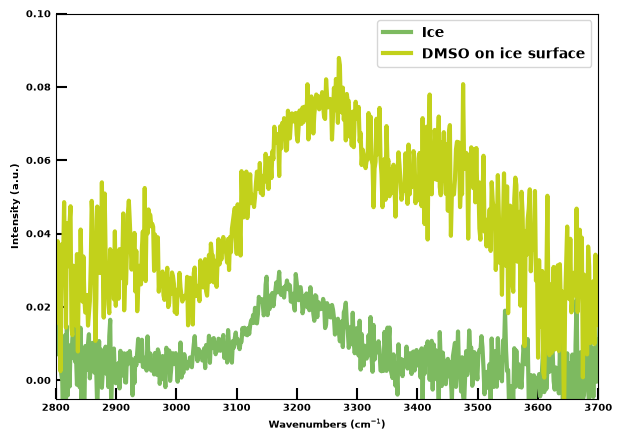

In [3]:
file_data = {
    'ice_ssp_3um_300s_a.csv': 'Ice',
    'ice_dmso_ssp_3um_600s_b.csv': 'DMSO on ice surface'
}

plt.figure(figsize=(7, 5))
plt.ylim(-0.005, 0.1) # Adjusted y-limit to accommodate both datasets
plt.xlim(2800, 3700)
plt.xticks(fontsize=7, fontweight='bold')
plt.yticks(fontsize=7, fontweight='bold')
plt.xlabel(r'Wavenumbers (cm$^{-1}$)', fontsize=7, fontweight='bold')
plt.ylabel('Intensity (a.u.)', fontsize=7, fontweight='bold')
#plt.title('Ice and DMSO on ice surface', fontsize=15, fontweight='bold')

# borders
ax = plt.gca()
#ax.spines['top'].set_linewidth(2.5)
#ax.spines['right'].set_linewidth(2.5)
#ax.spines['left'].set_linewidth(2)
#ax.spines['bottom'].set_linewidth(2)

plt.grid(False)

for filename, label in file_data.items():
    file_path = os.path.join(path, filename)
    try:
        # read the CSV with comma as delimiter, treating the first row as header
        df = pd.read_csv(file_path, sep=',', header=0, engine='python')

        # convert 'Wavenumber' and 'Intensity' to numeric
        df['Wavenumber'] = pd.to_numeric(df['Wavenumber'], errors='coerce')
        df['Intensity'] = pd.to_numeric(df['Intensity'], errors='coerce')

        # drop rows where either 'Wavenumber' or 'Intensity' is NaN (inf?)
        df.dropna(subset=['Wavenumber', 'Intensity'], inplace=True)

        # axes names
        x_data = df['Wavenumber']
        y_data = df['Intensity']

        # create an offset and assign colors
        if label == 'DMSO on ice surface':
            y_data = y_data + 0.01
            plot_color = '#c2d11b'  # Set color for DMSO
        else:
            plot_color = '#7dba60'   # Set color for Ice

        if not df.empty:
            plt.plot(x_data, y_data, label=label, lw=3, color=plot_color) # Added color argument
        else:
            print(f"No valid numeric data found for plotting in {filename} after cleaning.")

    except Exception as e:
        print(f"Error reading or plotting {filename}: {e}. Please check file format and column names.")

plt.legend(prop={'size': 10, 'weight': 'bold'})
#plt.legend(prop={'size': 10, 'weight': 'bold'}, frameon=False, loc='upper left', bbox_to_anchor=(1, 1))
plt.tick_params(axis='both', direction='in', length=8, width=1.5)
plt.show()

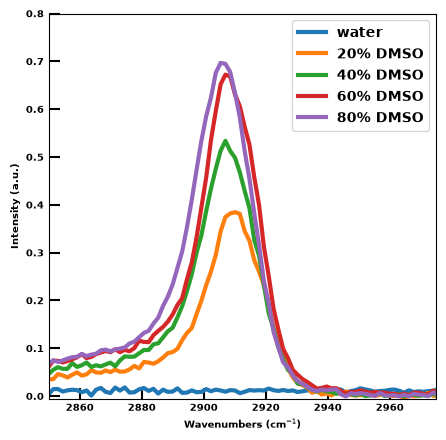

In [14]:
file_data = {
    'water_5C_ssp_3um_300s.csv': 'water',
    'dmso20_5C_ssp_3um_300s.csv': '20% DMSO',
    'dmso40_5C_ssp_3um_300s.csv': '40% DMSO',
    'dmso60_5C_ssp_3um_300s.csv': '60% DMSO',
    'dmso80_5C_ssp_3um_300s.csv': '80% DMSO',
    
}

plt.figure(figsize=(5, 5))
plt.ylim(-0.005, 0.8) # Adjusted y-limit to accommodate both datasets
plt.xlim(2850, 2975)
plt.xticks(fontsize=7, fontweight='bold')
plt.yticks(fontsize=7, fontweight='bold')
plt.xlabel(r'Wavenumbers (cm$^{-1}$)', fontsize=7, fontweight='bold')
plt.ylabel('Intensity (a.u.)', fontsize=7, fontweight='bold')
#plt.title('Ice and DMSO on ice surface', fontsize=15, fontweight='bold')

# borders
ax = plt.gca()
#ax.spines['top'].set_linewidth(2.5)
#ax.spines['right'].set_linewidth(2.5)
#ax.spines['left'].set_linewidth(2)
#ax.spines['bottom'].set_linewidth(2)

plt.grid(False)

for filename, label in file_data.items():
    file_path = os.path.join(path, filename)
    try:
        # read the CSV with comma as delimiter, treating the first row as header
        df = pd.read_csv(file_path, sep=',', header=0, engine='python')

        # convert 'Wavenumber' and 'Intensity' to numeric
        df['Wavenumber'] = pd.to_numeric(df['Wavenumber'], errors='coerce')
        df['Intensity'] = pd.to_numeric(df['Intensity'], errors='coerce')

        # drop rows where either 'Wavenumber' or 'Intensity' is NaN (inf?)
        df.dropna(subset=['Wavenumber', 'Intensity'], inplace=True)

        # axes names
        x_data = df['Wavenumber']
        y_data = df['Intensity']

        # create an offset and assign colors
        if label == 'water':
            color = 'blue'  # Set color
        if label == '20% DMSO':
            color = 'purple'   # Set color
        if label == '40% DMSO':
            color = 'orange'   # Set color
        if label == '60% DMSO':
            color = 'pink'   # Set color
        if label == '80% DMSO':
            color = 'green'   # Set color

        if not df.empty:
            plt.plot(x_data, y_data, label=label, lw=3) # Added color argument
        else:
            print(f"No valid numeric data found for plotting in {filename} after cleaning.")

    except Exception as e:
        print(f"Error reading or plotting {filename}: {e}. Please check file format and column names.")

plt.legend(prop={'size': 10, 'weight': 'bold'})
#plt.legend(prop={'size': 10, 'weight': 'bold'}, frameon=False, loc='upper left', bbox_to_anchor=(1, 1))
plt.tick_params(axis='both', direction='in', length=8, width=1.5)
plt.show()